# Sequence Processing with HMMs and CRFs

**The goal of this practical is to study sequence models in NLP.**

We will work on Part-Of-Speech (POS) and optionally on chunking (gathering different groups in sentences). The datasets are from [CONLL 2000](https://www.clips.uantwerpen.be/conll2000/chunking/): 
- **Small corpus:** chtrain/chtest to understand the tools and models 
- **Larger corpus:** train/test to collect reliable experimental results


# 1) HMMS


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading POS/Chunking data
def load(filename):
    listeDoc = list()
    with open(filename, "r") as f:
        doc = list()
        for ligne in f:
            if len(ligne) < 2: # fin de doc
                listeDoc.append(doc)
                doc = list()
                continue
            mots = ligne.replace("\n","").split(" ")
            doc.append((mots[0],mots[1])) # Change mots[1] -> mots[2] for chuncking
    return listeDoc

In [3]:
# =============== loding ============
# small corpus => ideal for first tests
filename = "../Dataset/conll2000/chtrain.txt" 
filenameT = "../Dataset/conll2000/chtest.txt" 

# Larger corpus => To valide perf.
# filename = "ressources/conll2000/train.txt" 
# filenameT = "ressources/conll2000/test.txt" 

alldocs = load(filename)
alldocsT = load(filenameT)

print(len(alldocs)," docs read")
print(len(alldocsT)," docs (T) read")

823  docs read
77  docs (T) read


In [4]:
print(alldocs[0])
print(alldocsT[0])

[('Rockwell', 'NNP'), ('International', 'NNP'), ('Corp.', 'NNP'), ("'s", 'POS'), ('Tulsa', 'NNP'), ('unit', 'NN'), ('said', 'VBD'), ('it', 'PRP'), ('signed', 'VBD'), ('a', 'DT'), ('tentative', 'JJ'), ('agreement', 'NN'), ('extending', 'VBG'), ('its', 'PRP$'), ('contract', 'NN'), ('with', 'IN'), ('Boeing', 'NNP'), ('Co.', 'NNP'), ('to', 'TO'), ('provide', 'VB'), ('structural', 'JJ'), ('parts', 'NNS'), ('for', 'IN'), ('Boeing', 'NNP'), ("'s", 'POS'), ('747', 'CD'), ('jetliners', 'NNS'), ('.', '.')]
[('Confidence', 'NN'), ('in', 'IN'), ('the', 'DT'), ('pound', 'NN'), ('is', 'VBZ'), ('widely', 'RB'), ('expected', 'VBN'), ('to', 'TO'), ('take', 'VB'), ('another', 'DT'), ('sharp', 'JJ'), ('dive', 'NN'), ('if', 'IN'), ('trade', 'NN'), ('figures', 'NNS'), ('for', 'IN'), ('September', 'NNP'), (',', ','), ('due', 'JJ'), ('for', 'IN'), ('release', 'NN'), ('tomorrow', 'NN'), (',', ','), ('fail', 'VB'), ('to', 'TO'), ('show', 'VB'), ('a', 'DT'), ('substantial', 'JJ'), ('improvement', 'NN'), ('from'

## Building a baseline POS model (without sequence)

We will build a simple dictionary ```word => PoS label``` without taking into account any sequence information. We will compare the sequence models to this baseline.

The dataset is a list a tuples with ```(word, POS)```. **Build a simple dictionary mapping each word to its PoS tag in the train set**

In [5]:
# Dictionary building 
allmaps = dict()
pos_tags_count = dict()
for docs in alldocs:
    for word, pos in docs:
        if not word.isalnum():
            continue
        
        v = pos_tags_count.get(pos, 0)
        pos_tags_count[pos] = v + 1
        
        if word not in allmaps:
            allmaps[word] = dict()
        v = allmaps[word].get(pos, 0)
        allmaps[word][pos] = v + 1

allmaps_freq = dict()
for word, pos_tags in allmaps.items():
    allmaps_freq[word] = max(pos_tags, key=pos_tags.get)

print(list(pos_tags_count.keys()))

max_pos_tag = max(pos_tags_count, key=pos_tags_count.get)
max_pos_tag


['NNP', 'NN', 'VBD', 'PRP', 'DT', 'JJ', 'VBG', 'PRP$', 'IN', 'TO', 'VB', 'NNS', 'CD', 'VBZ', 'VBP', 'VBN', 'CC', 'RB', 'WDT', 'WP', 'RBR', 'JJR', 'NNPS', 'MD', 'WRB', 'JJS', 'EX', 'WP$', 'RP', 'RBS', 'FW', 'PDT']


'NN'

In [6]:
from collections import defaultdict, Counter

allmaps_freq = defaultdict(Counter)
max_pos_tag = Counter()

# if a word has multiple pos tags, give priority to the most frequent one
for docs in alldocs:
    for word, pos in docs:

        max_pos_tag[pos] += 1
        allmaps_freq[word][pos] += 1

print("Number of POS tags =", len(max_pos_tag))
allmaps = {word:pos_counter.most_common(1)[0][0] for word, pos_counter in allmaps_freq.items()}
max_pos_tag = max_pos_tag.most_common(1)[0][0]
max_pos_tag

Number of POS tags = 42


'NN'

**Note: on the test set, there are unknown words...**. We will use the following simple strategy: 
```
# remplace
dico[cle] # crashing with an unknown key 
# by 
dico.get(cle, DefaultValue)
```
From a linguistic point of view, we can choose the default value as the majority PoS class, producing a stronger baseline.

In [36]:
# Evaluate test performances

total = sum(len(docs) for docs in alldocsT)
correct = sum(allmaps.get(word, max_pos_tag) == pos for docs in alldocsT for word, pos in docs)
print("Baseline accuracy=", correct / total, correct, total)

Baseline accuracy= 0.8169831223628692 1549 1896


Check: 1433 good predictions in test over 1896

(1527 with 'NN' as default PoS value)

## HMMs

Here is a code for training HMM parameters and running decoding using the Viterbi algorithm. You should apply it to our PoS task. **N.B.: you should undersand the ```eps``` parmaters**.


In [8]:
# allx: list of observation sequences 
# allq: list os state sequences 
# N: nb states
# K: nb observations

def learnHMM(allx, allq, N, K, initTo1=True):
    if initTo1:
        eps = 1e-1
        A = np.ones((N, N)) * eps
        B = np.ones((N, K)) * eps
        Pi = np.ones(N) * eps
    else:
        A = np.zeros((N, N))
        B = np.zeros((N, K))
        Pi = np.zeros(N)
    for x, q in zip(allx, allq):
        Pi[int(q[0])] += 1
        for i in range(len(q) - 1):
            A[int(q[i]), int(q[i + 1])] += 1
            B[int(q[i]), int(x[i])] += 1  # Correct: state, observation
        B[int(q[-1]), int(x[-1])] += 1  # Correct: last emission
    A = A / np.maximum(A.sum(1).reshape(N, 1), 1)
    B = B / np.maximum(B.sum(1).reshape(N, 1), 1)
    Pi = Pi / Pi.sum()
    return Pi, A, B

def viterbi(x,Pi,A,B):
    T = len(x)
    N = len(Pi)
    logA = np.log(A)
    logB = np.log(B)
    logdelta = np.zeros((N,T))
    psi = np.zeros((N,T), dtype=int)
    S = np.zeros(T)
    logdelta[:,0] = np.log(Pi) + logB[:,int(x[0])]
    #forward
    for t in range(1,T):
        logdelta[:,t] = (logdelta[:,t-1].reshape(N,1) + logA).max(0) + logB[:,int(x[t])]
        psi[:,t] = (logdelta[:,t-1].reshape(N,1) + logA).argmax(0)
    # backward
    logp = logdelta[:,-1].max()
    S[T-1] = logdelta[:,-1].argmax()
    for i in range(2,T+1):
        S[int(T-i)] = psi[int(S[int(T-i+1)]),int(T-i+1)]
    return S, logp #, delta, psi
 

### Data encoding

We will map each word to an index for traing the HMM (see code below):
```
 The cat is in the garden => 1 2 3 4 1 5
```
We have to understand the dictionary functionning to retrieve the words corresponding to indices.

In [9]:
# alldocs etant issu du chargement des données
# la mise en forme des données est fournie ici
# afin de produire des analyses qualitative, vous devez malgré tout comprendre le fonctionnement des dictionnaires

buf = [[m for m,pos in d ] for d in alldocs]
mots = []
[mots.extend(b) for b in buf]
mots = np.unique(np.array(mots))
nMots = len(mots)+1 # mot inconnu

mots2ind = dict(zip(mots,range(len(mots))))
mots2ind["UUUUUUUU"] = len(mots)

buf2 = [[pos for m,pos in d ] for d in alldocs]
cles = []
[cles.extend(b) for b in buf2]
cles = np.unique(np.array(cles))
cles2ind = dict(zip(cles,range(len(cles))))

nCles = len(cles)

print(nMots,nCles," in the dictionary")

# mise en forme des données
allx  = [[mots2ind[m] for m,pos in d] for d in alldocs]
allxT = [[mots2ind.setdefault(m,len(mots)) for m,pos in d] for d in alldocsT]

allq  = [[cles2ind[pos] for m,pos in d] for d in alldocs]
allqT = [[cles2ind.setdefault(pos,len(cles)) for m,pos in d] for d in alldocsT]

4570 42  in the dictionary


In [10]:
# First doc:
print(allx[0])
print(allq[0])

[1140, 814, 563, 11, 1294, 4393, 3855, 2854, 3992, 1362, 4242, 1452, 2395, 2855, 1990, 4529, 446, 525, 4299, 3595, 4148, 3368, 2499, 446, 11, 283, 2861, 20]
[18, 18, 18, 22, 18, 17, 32, 23, 32, 9, 13, 17, 33, 24, 17, 12, 18, 18, 29, 31, 13, 20, 12, 18, 22, 8, 20, 5]


## You turn: apply HMMs to those data!

In [11]:
# HMM training 

Pi, A, B = learnHMM(allx, allq, nCles, nMots)
S, logp = viterbi(allxT[0], Pi, A, B)
S

array([41., 12.,  9., 17., 36., 25., 34., 29., 31.,  9., 13., 20., 12.,
       17., 20., 12., 18.,  4., 13., 12.,  9., 17.,  4., 33., 29., 31.,
        9., 13., 17., 12., 18.,  7., 18., 22., 13., 20.,  5.])

In [ ]:
# HMM decoding and performances evaluation
# Evaluate test performances
total = sum(len(docs) for docs in alldocsT)
correct = sum(int(true_pos) == int(pred_pos) for i in range(len(allxT))
              for true_pos, pred_pos in zip(allqT[i],  viterbi(allxT[i], Pi, A, B)[0]))
print("HMM accuracy=", correct / total, correct, total)

HMM accuracy= 0.82542194092827 1565 1896


Check : 1564 in test

### Qualitative Analyis:

- With imshow on the parameters (ou d'un argsort), show what are the probable transition between labels.
- Visualize the confusion matrices to understand what is challenging in this task
- Find out examples that are corrected by Viterbi decoding



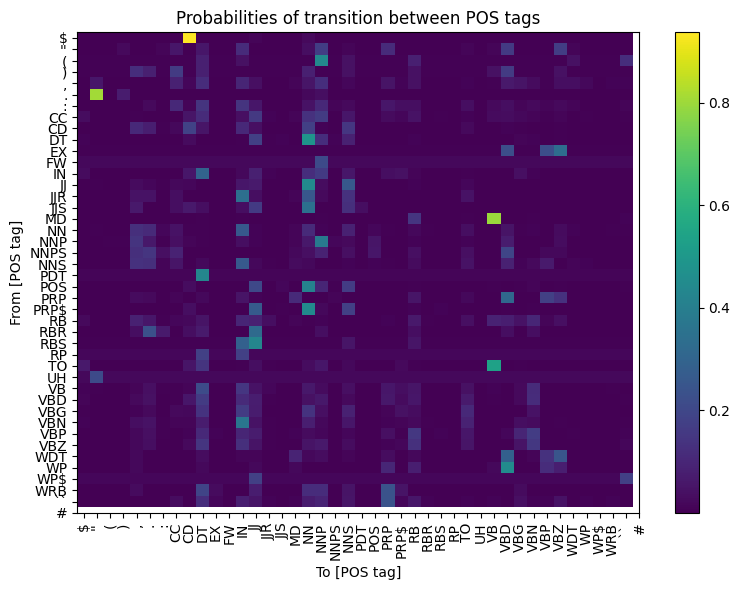

In [13]:
plt.figure(figsize=(8, 6))
plt.imshow(A, aspect="auto")
plt.xlabel("To [POS tag]")
plt.ylabel("From [POS tag]")
plt.colorbar()

plt.title("Probabilities of transition between POS tags")
labels = cles2ind.keys()
plt.xticks(range(len(labels)), labels, rotation=90);
plt.yticks(range(len(labels)), labels);
plt.tight_layout()

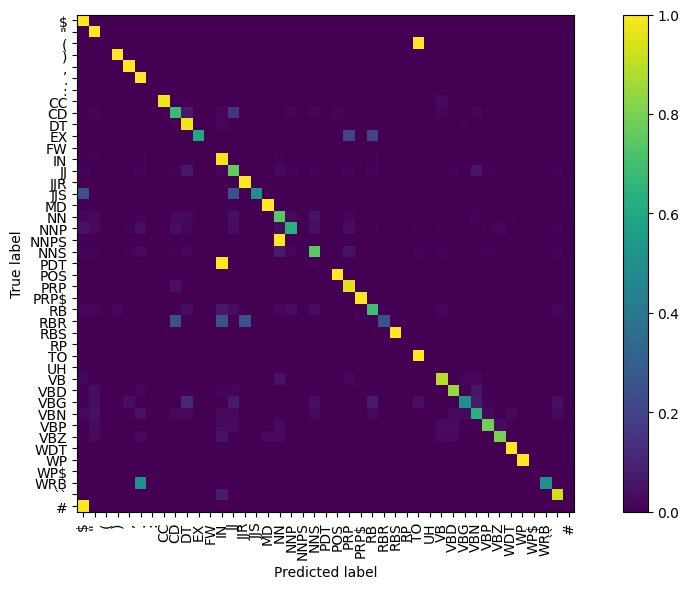

In [14]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ind2cles = {v:k for k, v in cles2ind.items()}

preds = np.array([ind2cles[pred_pos] for x in allxT for pred_pos in viterbi(x, Pi, A, B)[0]])
true = np.array([ind2cles[tag] for tags in allqT for tag in tags])

fig, ax = plt.subplots(figsize=(10, 6))
labels=sorted(cles2ind, key=cles2ind.get)
cm = confusion_matrix(true, preds, labels=labels, normalize="true")
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(ax=ax, include_values=False, cmap="viridis")
plt.xticks(rotation=90)
plt.tight_layout()


In [15]:
allmaps

{'Rockwell': 'NNP',
 'International': 'NNP',
 'Corp.': 'NNP',
 "'s": 'POS',
 'Tulsa': 'NNP',
 'unit': 'NN',
 'said': 'VBD',
 'it': 'PRP',
 'signed': 'VBD',
 'a': 'DT',
 'tentative': 'JJ',
 'agreement': 'NN',
 'extending': 'VBG',
 'its': 'PRP$',
 'contract': 'NN',
 'with': 'IN',
 'Boeing': 'NNP',
 'Co.': 'NNP',
 'to': 'TO',
 'provide': 'VB',
 'structural': 'JJ',
 'parts': 'NNS',
 'for': 'IN',
 '747': 'CD',
 'jetliners': 'NNS',
 '.': '.',
 'the': 'DT',
 'calls': 'VBZ',
 'supply': 'VB',
 '200': 'CD',
 'additional': 'JJ',
 'so-called': 'JJ',
 'shipsets': 'NNS',
 'planes': 'NNS',
 'These': 'DT',
 'include': 'VB',
 ',': ',',
 'among': 'IN',
 'other': 'JJ',
 'each': 'DT',
 'jetliner': 'NN',
 'two': 'CD',
 'major': 'JJ',
 'bulkheads': 'NNS',
 'pressure': 'NN',
 'floor': 'NN',
 'torque': 'NN',
 'box': 'NN',
 'fixed': 'VBN',
 'leading': 'VBG',
 'edges': 'NNS',
 'wings': 'NNS',
 'and': 'CC',
 'an': 'DT',
 'aft': 'JJ',
 'keel': 'NN',
 'beam': 'NN',
 'Under': 'IN',
 'existing': 'VBG',
 'has': 'VBZ'

In [16]:
# Examples corrected by Viterbi
ind2mots = {v:k for k, v in mots2ind.items()}
ind2cles = {v:k for k, v in cles2ind.items()}

for i, x in enumerate(allxT):
    pred_viterbi = np.array(viterbi(x, Pi, A, B)[0], dtype=int)
    pred_baseline = np.array([cles2ind[allmaps.get(ind2mots[w], max_pos_tag)] for w in x])
    true_tags = np.array(allqT[i])
    
    mask = (true_tags != pred_baseline) & (true_tags == pred_viterbi) 
    if not mask.any():
        continue

    print("Baseline predicted tags:", [(str(ind2mots[i]), str(ind2cles[i])) for i in pred_baseline[mask]])
    print("Viterbi predicted tags:", [(str(ind2mots[i]), str(ind2cles[i])) for i in pred_viterbi[mask]])
    print()

Baseline predicted tags: [('-LRB-', 'NN'), ('1.045', 'VBP'), ('-LRB-', 'NN'), ('-LRB-', 'NN')]
Viterbi predicted tags: [('0.4', 'RB'), ('1,174', 'VB'), (',', 'JJ'), ('.', 'NNS')]

Baseline predicted tags: [('-LRB-', 'NN'), ('-LRB-', 'NN'), ('-LRB-', 'NN'), ('1,200', 'VBD'), ('-LRB-', 'NN')]
Viterbi predicted tags: [('-RCB-', 'NNP'), ('-RCB-', 'NNP'), ('-RCB-', 'NNP'), ('1.03', 'VBN'), ('1,174', 'VB')]

Baseline predicted tags: [('-LRB-', 'NN')]
Viterbi predicted tags: [('1.03', 'VBN')]

Baseline predicted tags: [('-LRB-', 'NN')]
Viterbi predicted tags: [('1,174', 'VB')]

Baseline predicted tags: [('0.4', 'RB'), ('-LRB-', 'NN'), ('-LRB-', 'NN')]
Viterbi predicted tags: [(',', 'JJ'), ('-RCB-', 'NNP'), ('-RCB-', 'NNP')]

Baseline predicted tags: [('-LRB-', 'NN'), ('-LRB-', 'NN')]
Viterbi predicted tags: [(',', 'JJ'), ('-RCB-', 'NNP')]

Baseline predicted tags: [('1,174', 'VB'), ('1.045', 'VBP'), ('-LRB-', 'NN')]
Viterbi predicted tags: [('1.045', 'VBP'), ('1,174', 'VB'), ("'ll", 'CD')]

B

# 2) Conditional Random Fields (CRF)

**CRF are disciminative models** representing the conditional distribution $P( \mathbf{y} | \mathbf{x} , \mathbf{w})$:

$$ P( \mathbf{y} | \mathbf{x} , \mathbf{w})  = \frac{e^{\mathbf{w}^T  \psi(\mathbf{x},\mathbf{y}) } }{\sum\limits_{y' \in \mathcal{y}}e^{\mathbf{w}^T  \psi(\mathbf{x},\mathbf{y}') } } $$ 
        
**In 'linear-chain' CRFs**, the feature functions include **unary terms $u_k$** ($\sim$ $\mathbf{B}$ matrix in HMMs) and **pairwise terms $p_k$** ($\sim$ $\mathbf{A}$ matrix in HMMs):

$$ \mathbf{w}^T \psi(\mathbf{x},\mathbf{y}) = \sum\limits_{t=1}^T \sum_{k=1}^K F_k(y_{t-1}, y_t, \mathbf{x})  =   \sum\limits_{t=1}^T \sum_{k=1}^K \left[ u_k(y_t, \mathbf{x}) + p_k(y_{t-1}, y_t, \mathbf{x}) \right]$$

[<img src="https://thome.isir.upmc.fr/classes/RITAL/crf-obs2.png" width="800" >](https://thome.isir.upmc.fr/classes/RITAL/crf-obs2.png)


We can directly use resources from nltk: 
- [CRFTagger](https://tedboy.github.io/nlps/generated/generated/nltk.CRFTagger.html)
- [PerceptronTagger](https://www.nltk.org/_modules/nltk/tag/perceptron.html)

In [ ]:
# !pip install python-crfsuite
from nltk.tag.crf import CRFTagger
tagger = CRFTagger()
tagger.train(alldocs, 'out/crf.model') # training


In [35]:
total = sum(len(docs) for docs in alldocsT)
correct = sum(true_tag == pred_tag for true_doc, pred_doc in zip(alldocsT, preds)
              for (_, true_tag), (_, pred_tag) in zip(true_doc, pred_doc))
print("CFRTagger accuracy=", correct/total)

CFRTagger accuracy= 0.9071729957805907


### Training and evaluating the model, as before

Check: 1720 bonnes réponses

In [ ]:
# perceptron
from nltk.tag.perceptron    import PerceptronTagger
tagger = PerceptronTagger(load=False)
tagger.train(alldocs)

Check: 1737 bonnes réponses

# Going further

- We test the application for PoS, we can run similar experiments for chunking (see parsing indication, very simple to load data)
- Run  experiement on the larger dataset. This dataset is still largely used in research. This work can thus be included in your resume :)
- Work will be purshed with word embeddings (next practical), and for [NER](https://www.clips.uantwerpen.be/conll2003/ner/) with RNNs (X. Tannier)
- [State-of-the-art resources](https://github.com/stanfordnlp/stanza/)